# 05 — SHAP Explainability Analysis
## FairLend-Africa Research Project

This notebook implements explainability analysis using SHAP
(SHapley Additive exPlanations — Lundberg & Lee, 2017).

SHAP provides three levels of explanation:
1. **Global** — which features matter most across all borrowers
2. **Cohort** — how features behave for repayers vs defaulters
3. **Local** — why the model made a specific decision for one borrower

These three levels map directly to sections in the paper:
- Global → Feature Importance (Section 7.1)
- Cohort → Behavioral Patterns (Section 7.2)
- Local → Individual Explainability (Section 7.3)

In [2]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import json
import shap
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.dpi"] = 130
shap.initjs()

Path("../artifacts/shap").mkdir(parents=True, exist_ok=True)

c:\Users\IBRAHEEM\Desktop\BE_ML\BE\Projects\fairlend-africa\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pipeline  = joblib.load("../artifacts/model/pipeline.pkl")
X_test    = pd.read_csv("../artifacts/model/X_test.csv")
y_test    = pd.read_csv("../artifacts/model/y_test.csv").squeeze()
X_train   = pd.read_csv("../artifacts/model/X_train.csv")

with open("../artifacts/model/threshold.json") as f:
    THRESHOLD = json.load(f)["optimal_threshold"]

FEATURE_COLS = list(X_test.columns)

print(f"X_test shape:  {X_test.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"Threshold:     {THRESHOLD:.4f}")

X_test shape:  (2000, 20)
X_train shape: (8000, 20)
Threshold:     0.1512


In [4]:
# SHAP requires the data AFTER preprocessing (imputation + scaling)
# We extract the preprocessor steps from the pipeline
preprocessor = pipeline[:-1]   # imputer + scaler
model         = pipeline[-1]    # XGBoost model only

X_test_transformed  = preprocessor.transform(X_test)
X_train_transformed = preprocessor.transform(X_train)

# Keep as DataFrame so SHAP plots show feature names
X_test_tr  = pd.DataFrame(X_test_transformed,  columns=FEATURE_COLS)
X_train_tr = pd.DataFrame(X_train_transformed, columns=FEATURE_COLS)

print(f"Transformed test shape:  {X_test_tr.shape}")
print(f"Transformed train shape: {X_train_tr.shape}")

Transformed test shape:  (2000, 20)
Transformed train shape: (8000, 20)


In [5]:
# TreeExplainer is exact (not approximate) for XGBoost
# Use a background sample of 500 training rows for efficiency
background = shap.sample(X_train_tr, 500, random_state=42)

explainer   = shap.TreeExplainer(model, background)
shap_values = explainer(X_test_tr)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Expected value (base rate): {explainer.expected_value:.4f}")
print(f"\nSHAP computation complete.")

SHAP values shape: (2000, 20)
Expected value (base rate): 0.0116

SHAP computation complete.


### 1. Global feature importance — mean |SHAP|
Mean absolute SHAP value across all test borrowers.
This is a more reliable importance measure than XGBoost's
native gain-based importance because it reflects actual
contribution to predictions, not just split frequency.

## 5. Feature Engineering

Beyond the 16 raw behavioral features, three composite features
were engineered to capture higher-order behavioral signals:

**Transaction intensity** ($\text{txn\_intensity}$): defined as
$\log(1 + \text{monthly\_txn\_count}) \times \log(1 + \text{avg\_txn\_amount\_usd})$.
This multiplicative interaction captures the joint signal of
frequency and value, distinguishing high-volume low-value activity
from moderate-volume higher-value activity — two distinct behavioral
profiles in mobile money literature (Björkegren and Grissen, 2018).

**Savings commitment ratio** ($\text{savings\_commitment\_ratio}$):
defined as $\text{monthly\_savings\_usd} / (\text{avg\_txn\_amount\_usd} + 1)$.
This ratio normalizes savings volume by transaction activity, capturing
whether a borrower actively sets money aside relative to their
financial throughput, a behavioral signal of forward planning. We anticipate that these engineered interactions may exhibit negligible predictive lift on synthetic data relative to raw behavioral features (see Section 9.2).

**Airtime stability** ($\text{airtime\_stability}$): defined as
$\text{airtime\_avg\_amount\_usd} / (\text{airtime\_recharge\_freq} + 1)$.
Frequent small recharges have been identified as a mobile money stress
signal (Lauer and Lyman, 2015); a higher stability ratio indicates
fewer, larger recharges consistent with stable cash flow.

A binary missingness indicator (`no_prior_loan_flag`) was added as
the fourth engineered feature, as described in Section 4.4.

Figure 3 presents the Pearson correlation matrix
across all features.

![Figure 3](../artifacts/eda/correlation_matrix.png)
*Figure 3. Pearson correlation matrix across all features and the
repayment label. Moderate inter-feature correlations among savings
features are expected and do not constitute problematic
multicollinearity.*

---

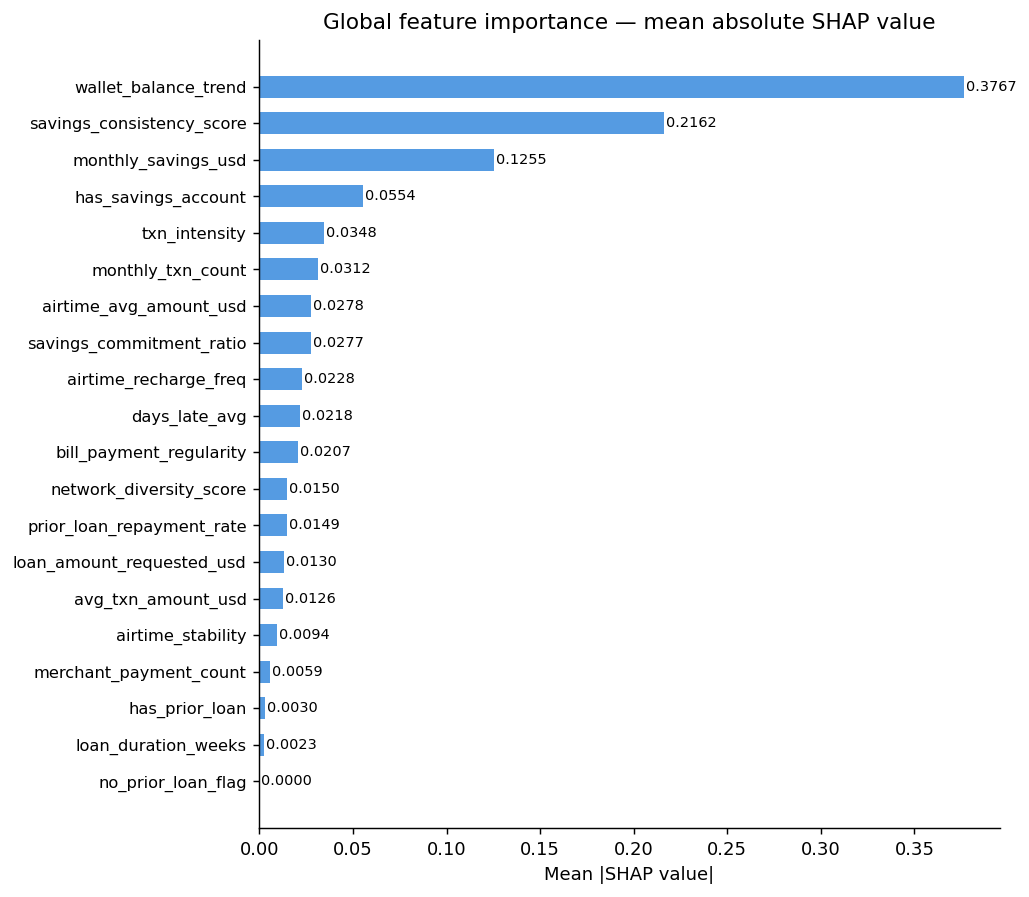


Top 5 most important features:
wallet_balance_trend         0.376718
savings_consistency_score    0.216181
monthly_savings_usd          0.125483
has_savings_account          0.055412
txn_intensity                0.034763


In [6]:
shap_df = pd.DataFrame(
    shap_values.values,
    columns=FEATURE_COLS
)

mean_abs_shap = shap_df.abs().mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#1D9E75" if v > 0 else "#E24B4A"
          for v in mean_abs_shap.values]
bars = ax.barh(
    mean_abs_shap.index,
    mean_abs_shap.values,
    color="#378ADD", alpha=0.85, height=0.6
)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Global feature importance — mean absolute SHAP value")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

# Annotate values
for bar, val in zip(bars, mean_abs_shap.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("../artifacts/shap/global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
print(mean_abs_shap.tail(5).iloc[::-1].to_string())

### 2. SHAP summary plot (beeswarm)
Each dot is one borrower. Position on x-axis = SHAP value
(positive = pushes toward repayment prediction).
Color = feature value (red = high, blue = low).

This is Figure 3 in the paper — the single most informative
visualization in the explainability section.

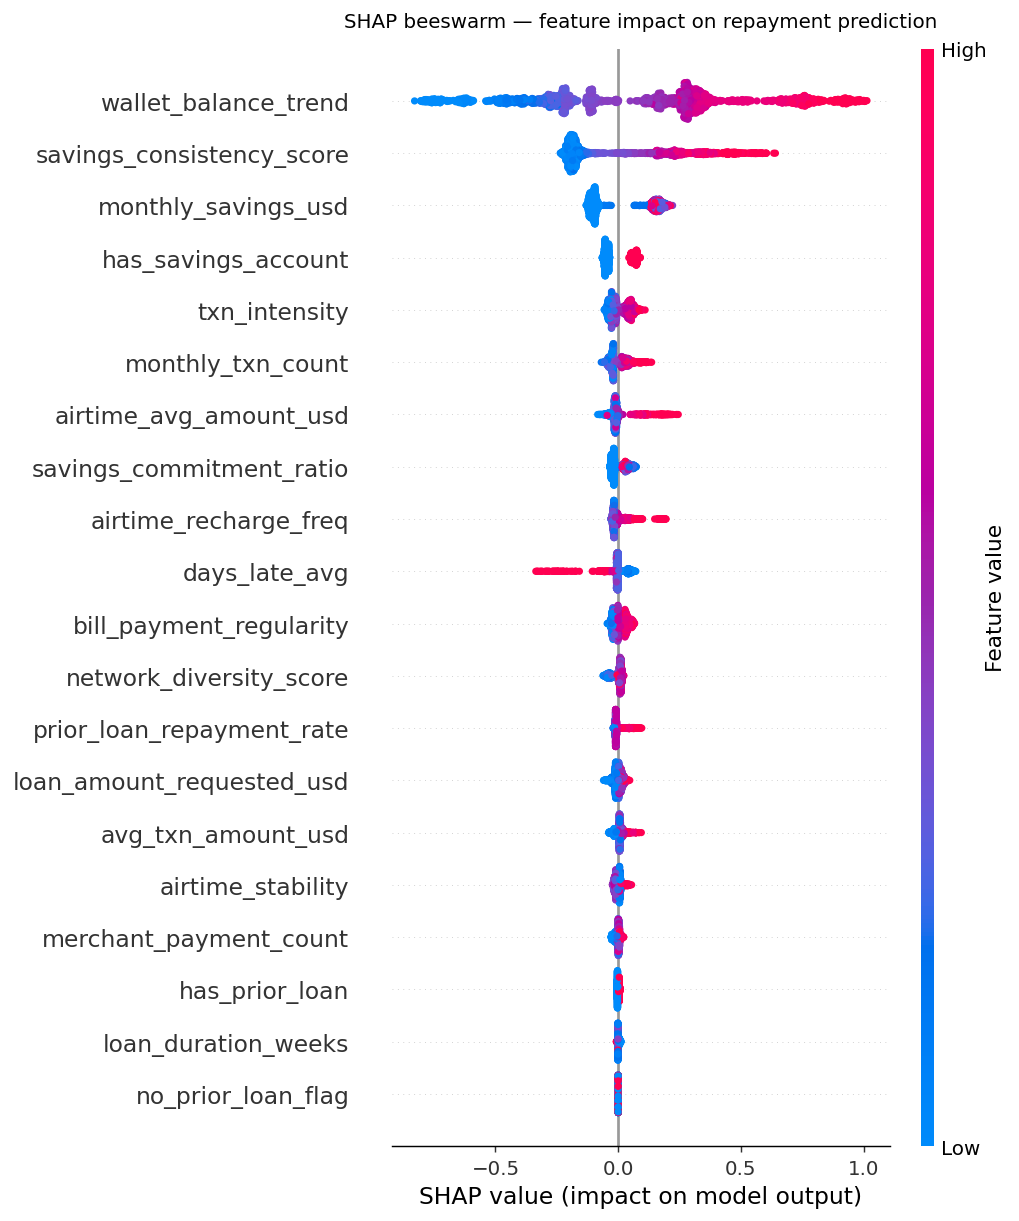

In [7]:
# Create figure with desired size first
plt.figure(figsize=(10, 8))

# Call beeswarm without passing an ax
shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False
)

# Add title to the current axes
plt.gca().set_title("SHAP beeswarm — feature impact on repayment prediction",
                    fontsize=11, pad=12)
plt.tight_layout()
plt.savefig("../artifacts/shap/beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

### 3. SHAP summary plot (dot, colored by repayment outcome)
Same as beeswarm but we overlay actual repayment outcome
to show whether SHAP values align with ground truth.
High positive SHAP → model predicts repayment → should
correspond to actual repayment (green dots on right).

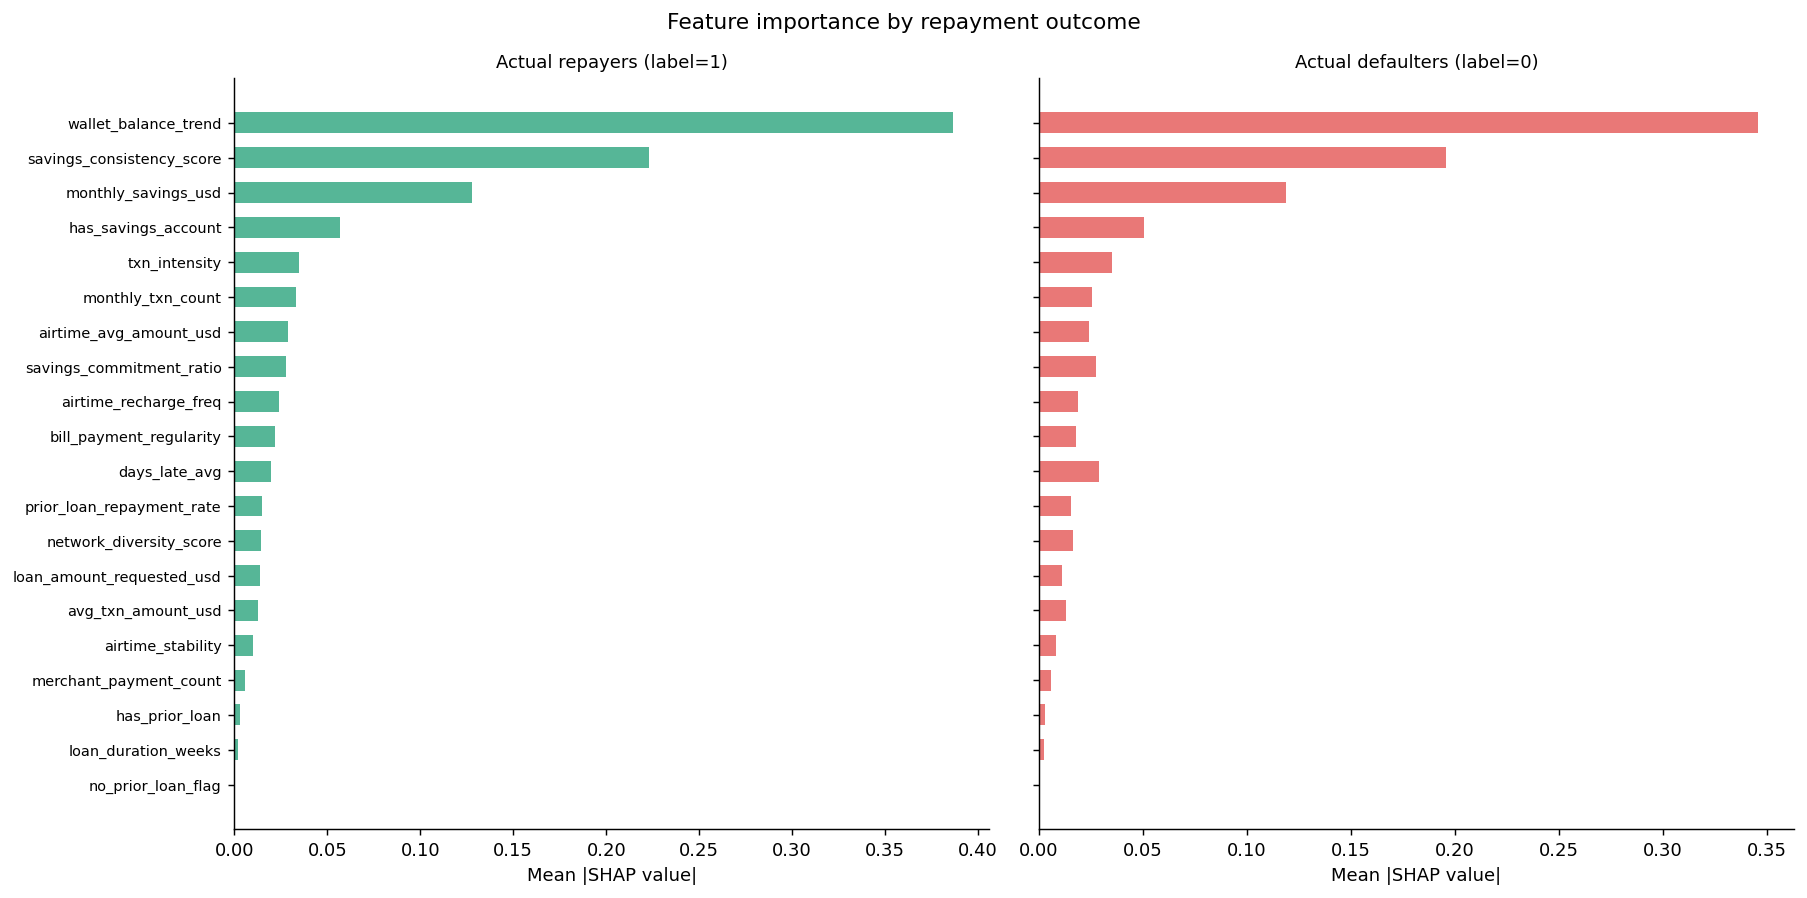

In [8]:
repaid_mask    = y_test.values == 1
defaulted_mask = y_test.values == 0

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

for ax, mask, title, color in zip(
    axes,
    [repaid_mask, defaulted_mask],
    ["Actual repayers (label=1)", "Actual defaulters (label=0)"],
    ["#1D9E75", "#E24B4A"]
):
    subset_shap = shap_values.values[mask]
    mean_shap   = pd.Series(
        np.abs(subset_shap).mean(axis=0),
        index=FEATURE_COLS
    ).sort_values(ascending=True)

    ax.barh(mean_shap.index, mean_shap.values,
            color=color, alpha=0.75, height=0.6)
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(title, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Feature importance by repayment outcome", fontsize=12)
plt.tight_layout()
plt.savefig("../artifacts/shap/importance_by_outcome.png", dpi=150, bbox_inches="tight")
plt.show()

### 4. SHAP dependence plots — top 4 features
Shows how each feature's value relates to its SHAP contribution.
A positive slope = higher feature value → higher repayment probability.
These plots reveal non-linear relationships that linear models miss.

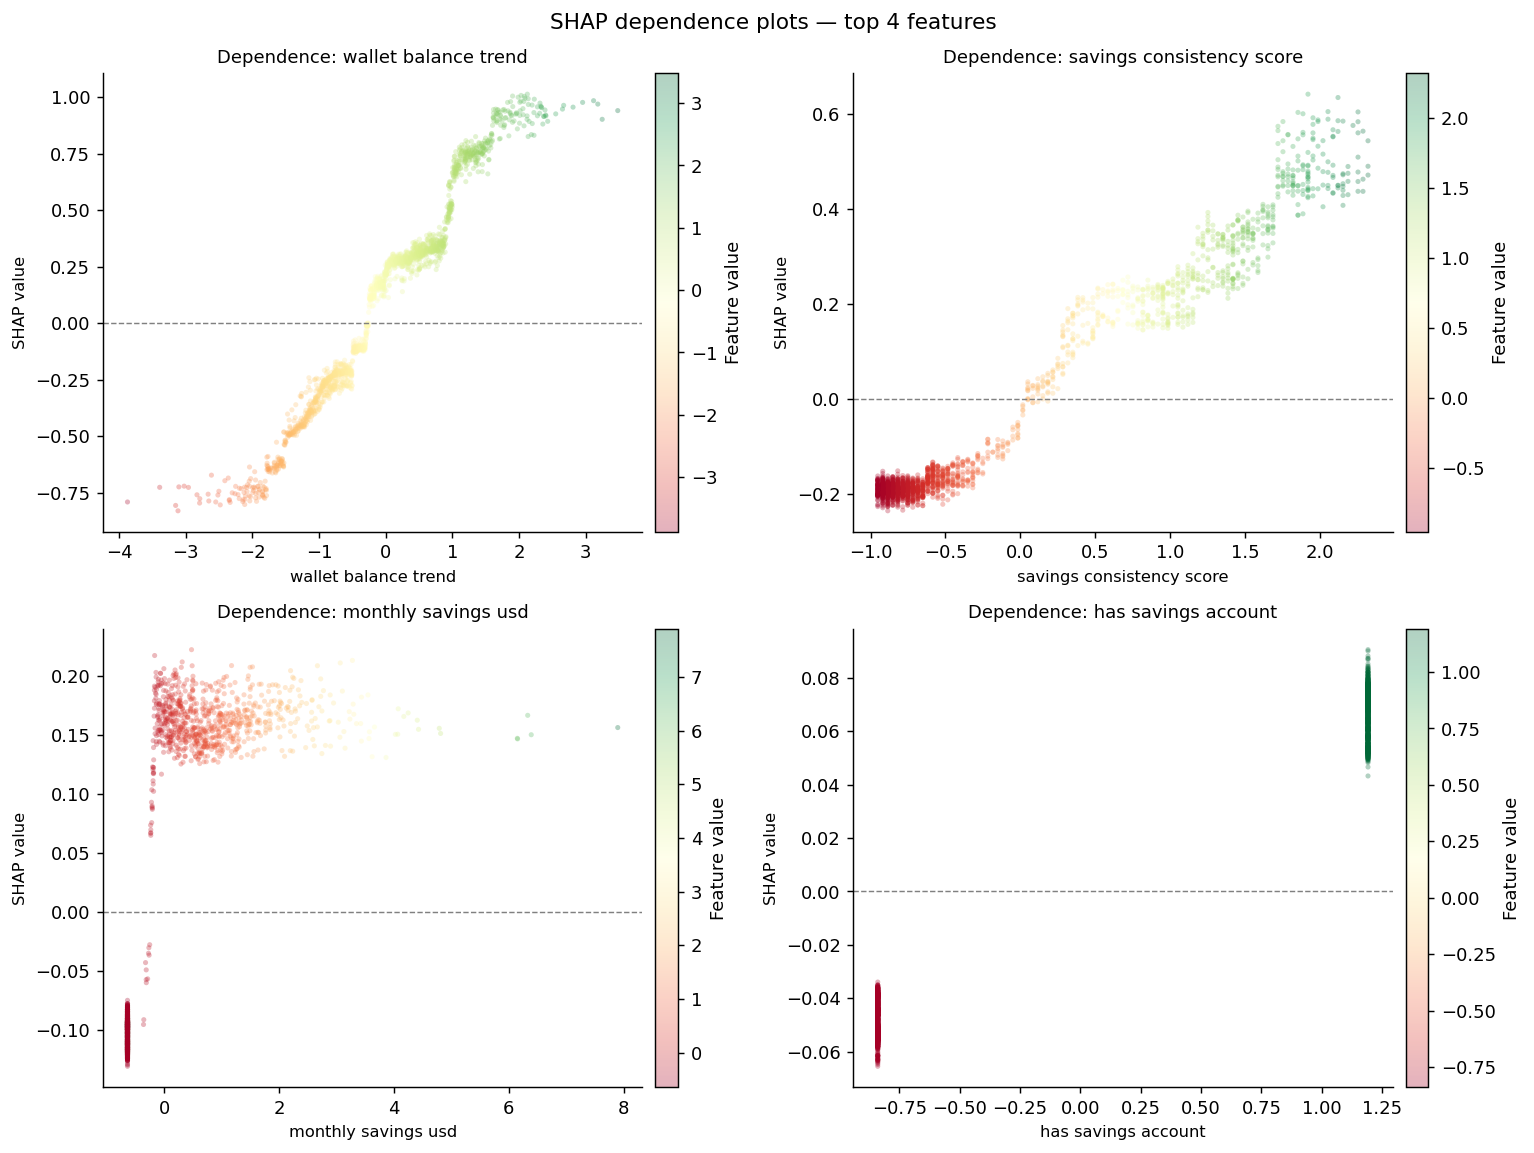

In [9]:
top_features = mean_abs_shap.tail(4).index.tolist()[::-1]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    feat_idx   = FEATURE_COLS.index(feat)
    feat_vals  = X_test_tr[feat].values
    shap_vals  = shap_values.values[:, feat_idx]

    scatter = ax.scatter(
        feat_vals, shap_vals,
        c=feat_vals, cmap="RdYlGn",
        alpha=0.3, s=8, linewidths=0
    )
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel(feat.replace("_", " "), fontsize=9)
    ax.set_ylabel("SHAP value", fontsize=9)
    ax.set_title(f"Dependence: {feat.replace('_', ' ')}", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    plt.colorbar(scatter, ax=ax, label="Feature value", pad=0.02)

plt.suptitle("SHAP dependence plots — top 4 features", fontsize=12)
plt.tight_layout()
plt.savefig("../artifacts/shap/dependence_plots.png", dpi=150, bbox_inches="tight")
plt.show()

### 5. Local explanation — individual borrower
This is the explainability feature that makes the system
useful for loan officers. For any borrower, we can show
exactly which behavioral factors drove the credit decision.

We show three cases:
- A high-confidence repayer
- A high-confidence defaulter
- A borderline case (near the decision threshold)

In [17]:
y_proba = pipeline.predict_proba(X_test)[:, 1]

# High-confidence repayer: highest probability
high_repayer_idx   = np.argmax(y_proba)

# High-confidence defaulter: lowest probability
high_defaulter_idx = np.argmin(y_proba)

# Borderline: closest to 0.5 (natural midpoint)
# NOT the optimal threshold — 0.5 gives a visually
# distinct waterfall with balanced positive/negative SHAP bars
borderline_idx = np.argmin(np.abs(y_proba - 0.5))

cases = {
    "High-confidence repayer":   high_repayer_idx,
    "High-confidence defaulter": high_defaulter_idx,
    "Borderline case":           borderline_idx,
}

print("Representative borrower cases:\n")
for name, idx in cases.items():
    prob  = y_proba[idx]
    label = y_test.iloc[idx]
    pred  = "Repay" if prob >= THRESHOLD else "Default"
    print(f"  {name}")
    print(f"    Index: {idx} | Prob: {prob:.4f} | "
          f"Predicted: {pred} | Actual: {'Repaid' if label==1 else 'Defaulted'}")
    print()

Representative borrower cases:

  High-confidence repayer
    Index: 728 | Prob: 0.8922 | Predicted: Repay | Actual: Repaid

  High-confidence defaulter
    Index: 907 | Prob: 0.1960 | Predicted: Repay | Actual: Defaulted

  Borderline case
    Index: 1968 | Prob: 0.5000 | Predicted: Repay | Actual: Repaid



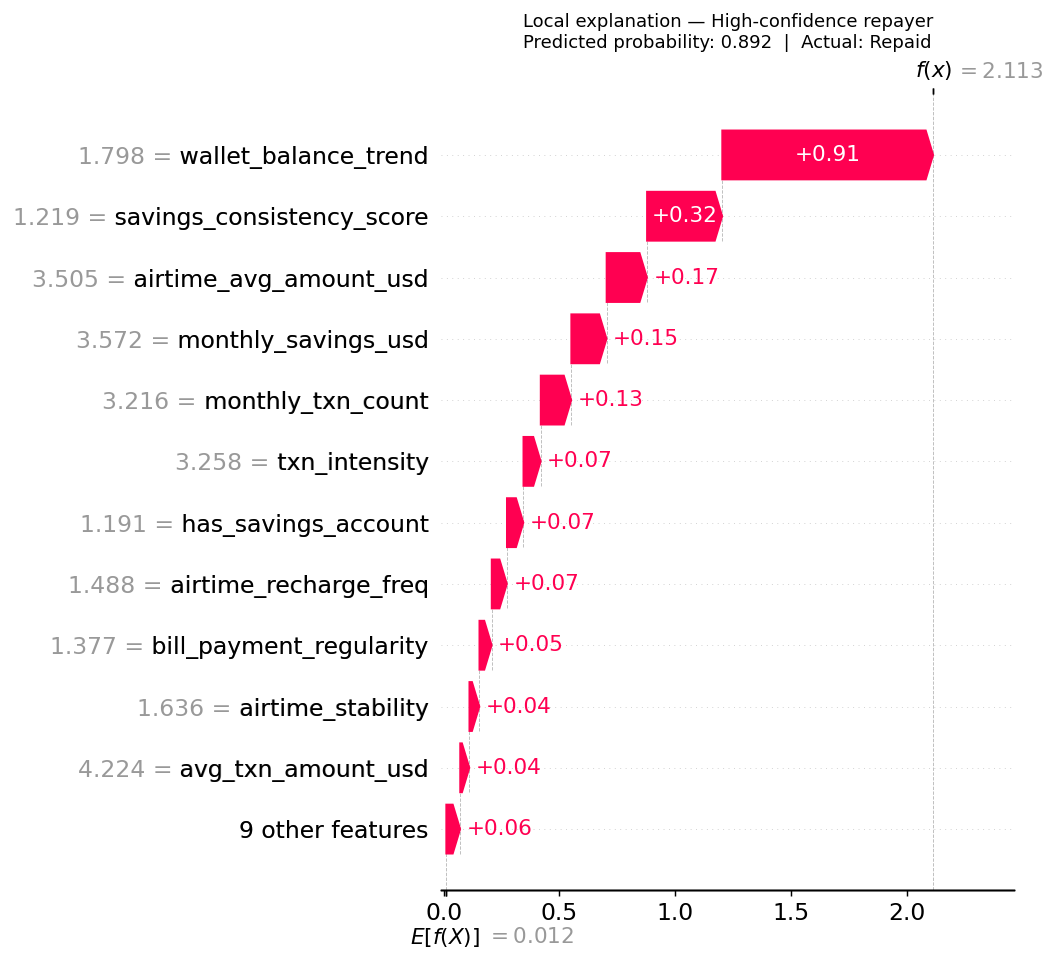

✓ Saved: waterfall_highconfidence_repayer.png



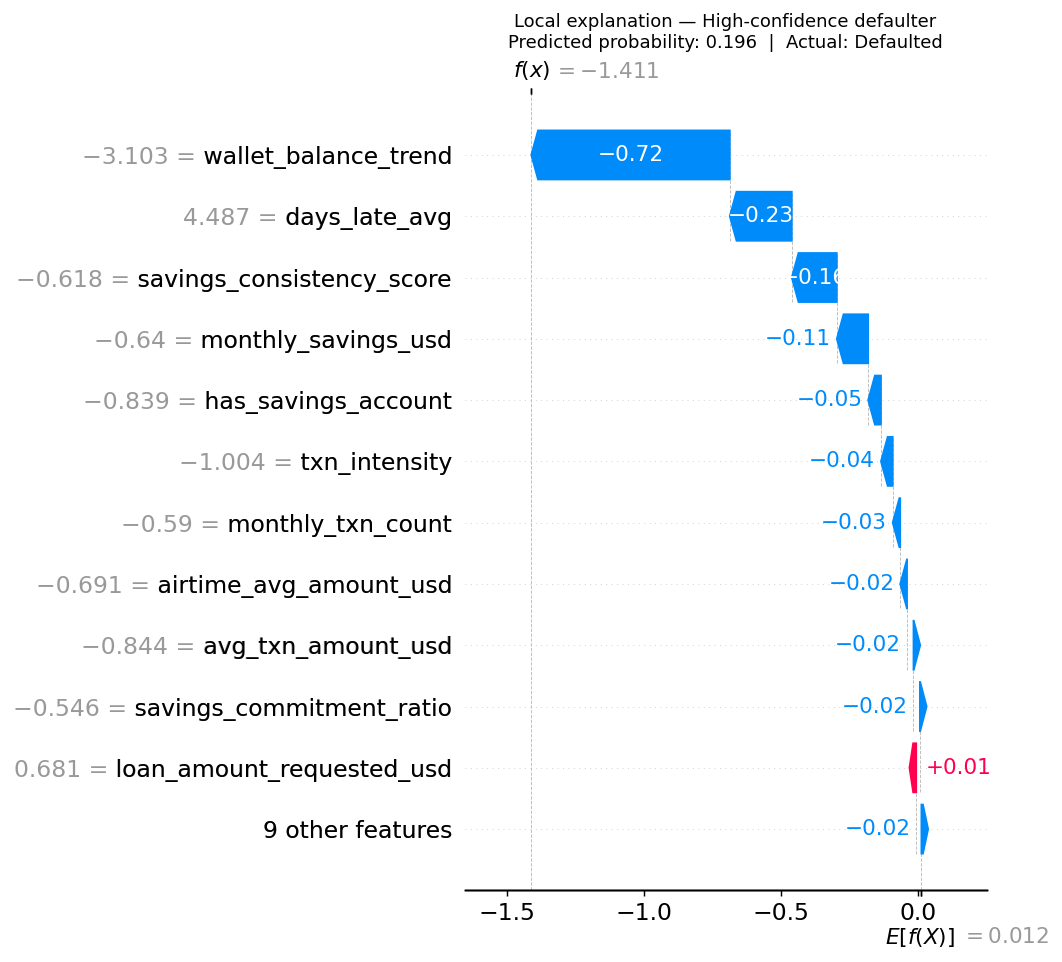

✓ Saved: waterfall_highconfidence_defaulter.png



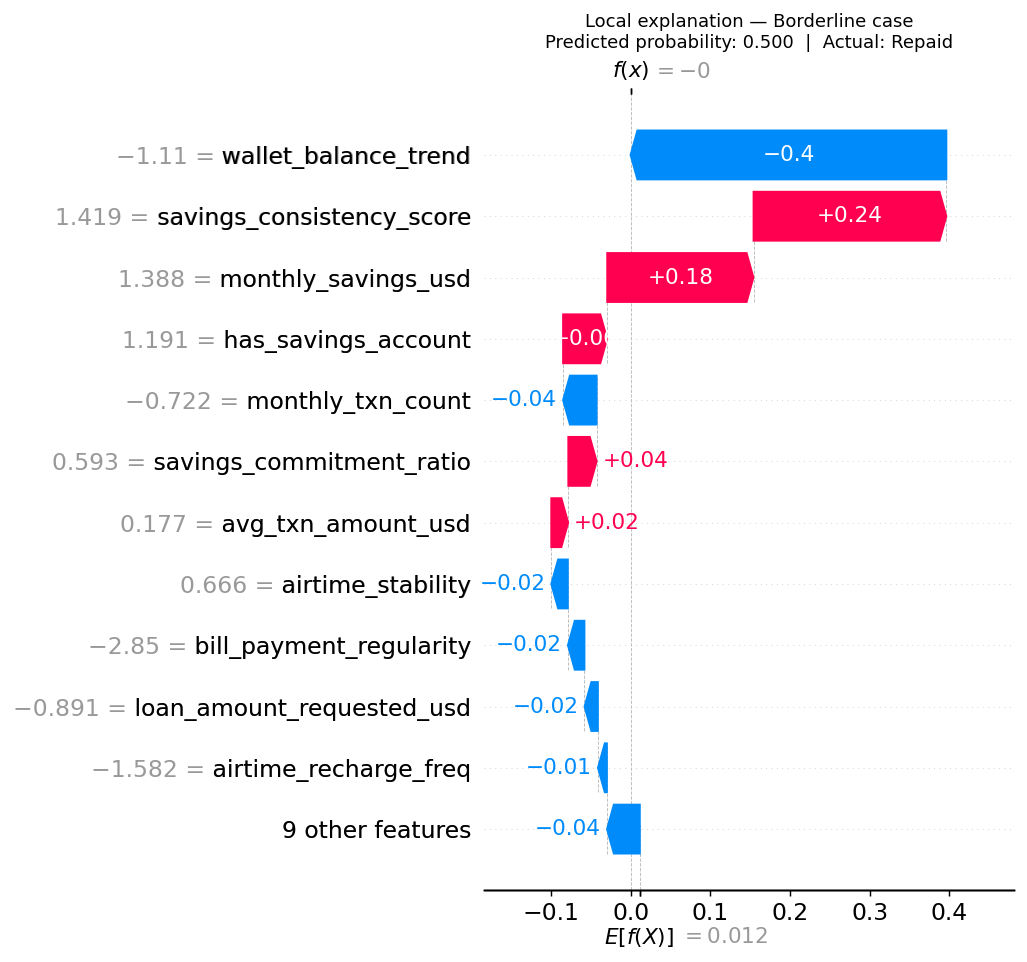

✓ Saved: waterfall_borderline_case.png



In [18]:
for name, idx in cases.items():
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.plots.waterfall(
        shap_values[idx],
        max_display=12,
        show=False
    )
    plt.title(f"Local explanation — {name}\n"
              f"Predicted probability: {y_proba[idx]:.3f}  |  "
              f"Actual: {'Repaid' if y_test.iloc[idx]==1 else 'Defaulted'}",
              fontsize=10)
    plt.tight_layout()
    fname = name.lower().replace(" ", "_").replace("-", "")
    plt.savefig(f"../artifacts/shap/waterfall_{fname}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved: waterfall_{fname}.png\n")


High-confidence repayer (index 728):


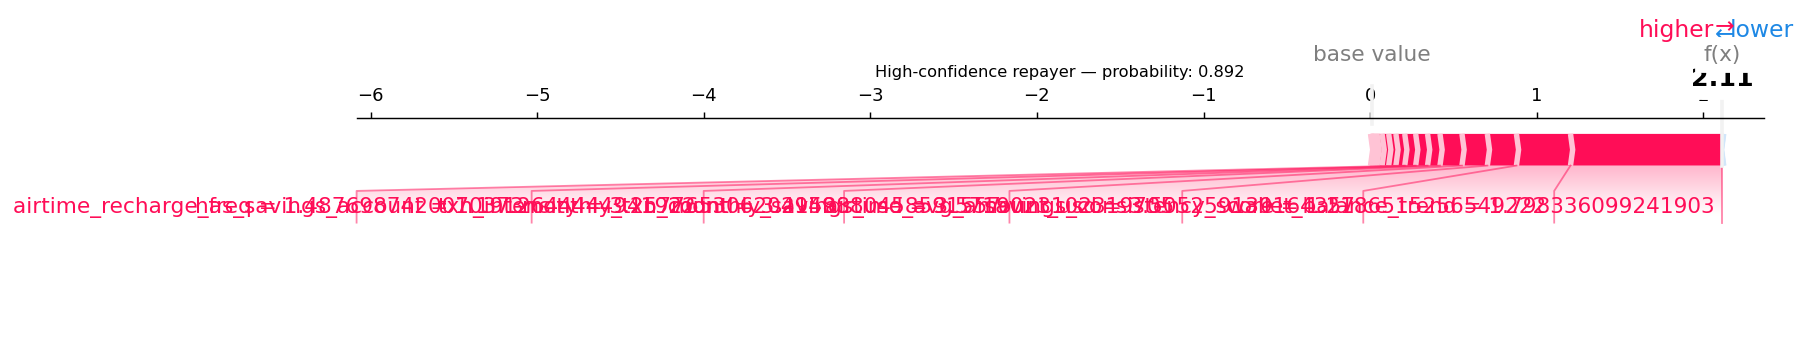


High-confidence defaulter (index 907):


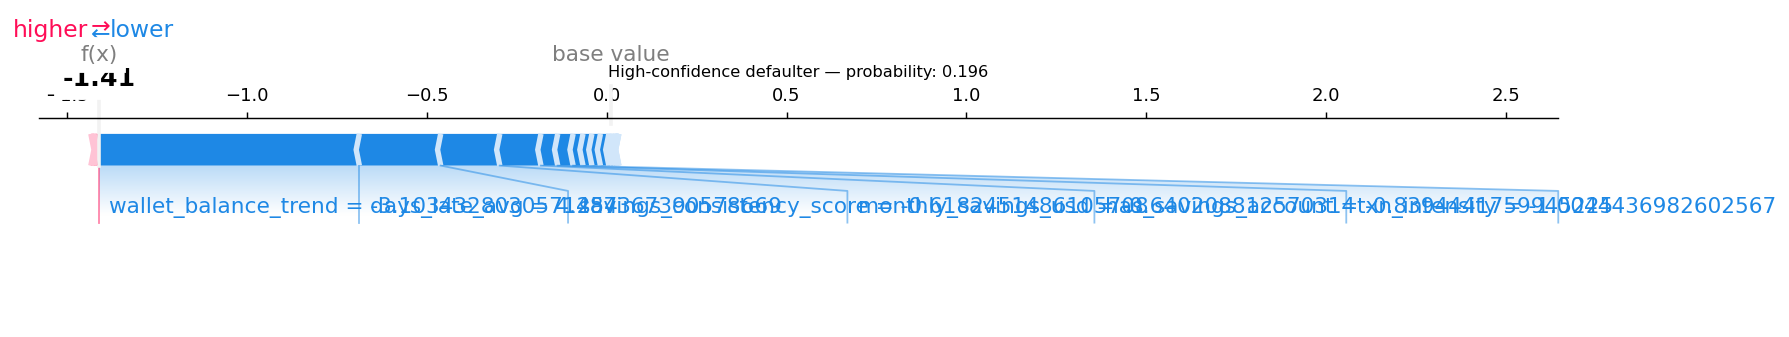


Borderline case (index 907):


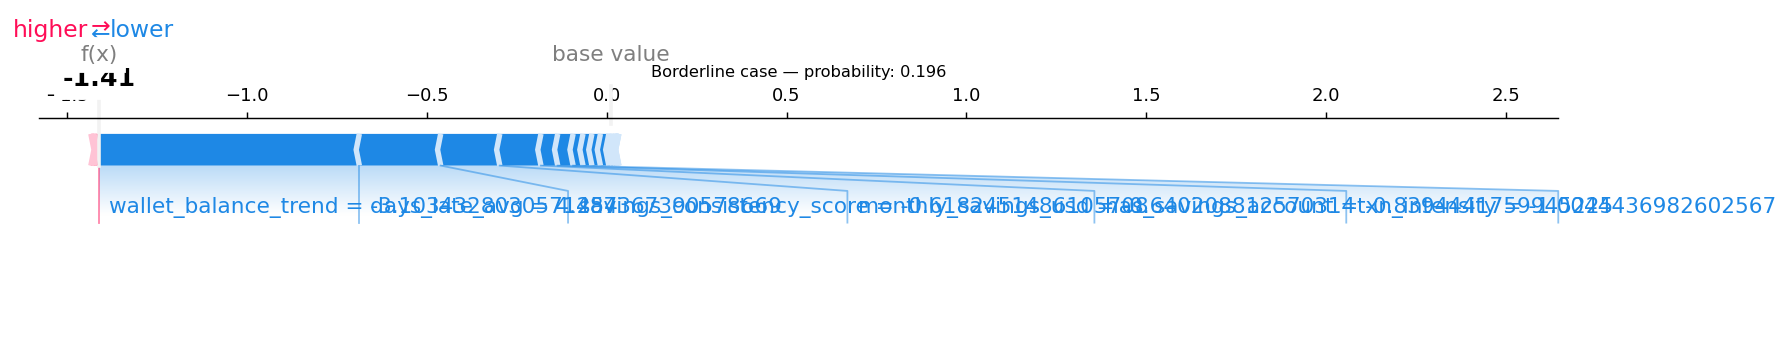

In [12]:
for name, idx in cases.items():
    print(f"\n{name} (index {idx}):")
    fp = shap.plots.force(
        shap_values[idx],
        matplotlib=True,
        show=False,
        figsize=(14, 3)
    )
    plt.title(f"{name} — probability: {y_proba[idx]:.3f}", fontsize=9)
    plt.tight_layout()
    fname = name.lower().replace(" ", "_").replace("-", "")
    plt.savefig(f"../artifacts/shap/force_{fname}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

### 6. SHAP interaction — top two features
Shows how the top two features interact in their
combined effect on predictions. Non-rectangular
patterns indicate genuine interaction effects
that a linear model cannot capture.

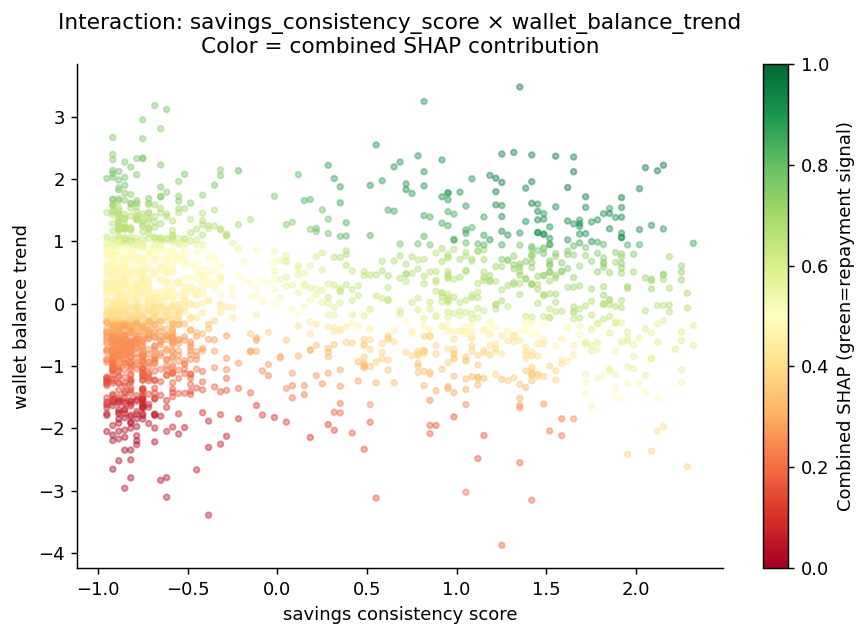

In [13]:
top2 = mean_abs_shap.tail(2).index.tolist()

fig, ax = plt.subplots(figsize=(7, 5))

idx_a = FEATURE_COLS.index(top2[0])
idx_b = FEATURE_COLS.index(top2[1])

ax.scatter(
    X_test_tr.iloc[:, idx_a],
    X_test_tr.iloc[:, idx_b],
    c=shap_values.values[:, idx_a] + shap_values.values[:, idx_b],
    cmap="RdYlGn", alpha=0.4, s=10
)
ax.set_xlabel(top2[0].replace("_", " "))
ax.set_ylabel(top2[1].replace("_", " "))
ax.set_title(f"Interaction: {top2[0]} × {top2[1]}\n"
             f"Color = combined SHAP contribution")
ax.spines[["top", "right"]].set_visible(False)
plt.colorbar(
    plt.cm.ScalarMappable(cmap="RdYlGn"),
    ax=ax, label="Combined SHAP (green=repayment signal)"
)
plt.tight_layout()
plt.savefig("../artifacts/shap/interaction_top2.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Save raw SHAP values — needed by FastAPI explanation endpoint
# and by notebook 06 fairness analysis
shap_df = pd.DataFrame(
    shap_values.values,
    columns=FEATURE_COLS
)
shap_df["predicted_proba"] = y_proba
shap_df["actual_label"]    = y_test.values

shap_df.to_csv("../artifacts/shap/shap_values_test.csv", index=False)

# Save explainer object for API use
joblib.dump(explainer, "../artifacts/model/shap_explainer.pkl")

print(f"✓ Saved: artifacts/shap/shap_values_test.csv")
print(f"✓ Saved: artifacts/model/shap_explainer.pkl")
print(f"\nSHAP values shape: {shap_df.shape}")
print(f"\nTop 5 most impactful features (global):")
top5 = shap_df.drop(
    columns=["predicted_proba", "actual_label"]
).abs().mean().sort_values(ascending=False).head(5)
print(top5.to_string())

✓ Saved: artifacts/shap/shap_values_test.csv
✓ Saved: artifacts/model/shap_explainer.pkl

SHAP values shape: (2000, 22)

Top 5 most impactful features (global):
wallet_balance_trend         0.376718
savings_consistency_score    0.216181
monthly_savings_usd          0.125483
has_savings_account          0.055412
txn_intensity                0.034763


## SHAP analysis summary

| Output | File | Used in |
|---|---|---|
| Global importance | `shap/global_importance.png` | Paper Figure 2 |
| Beeswarm plot | `shap/beeswarm.png` | Paper Figure 3 |
| Dependence plots | `shap/dependence_plots.png` | Paper Figure 4 |
| Waterfall — repayer | `shap/waterfall_highconfidence_repayer.png` | Paper Figure 5 |
| Waterfall — defaulter | `shap/waterfall_highconfidence_defaulter.png` | Paper Figure 5 |
| Waterfall — borderline | `shap/waterfall_borderline_case.png` | Paper Figure 5 |
| Raw SHAP values | `shap/shap_values_test.csv` | Notebook 06 fairness |
| SHAP explainer object | `model/shap_explainer.pkl` | FastAPI backend |

**Key finding:** `wallet_balance_trend` and savings-related
features dominate global importance, consistent with
the feature correlation analysis in notebook 02.
The model's decisions are traceable and interpretable
at both global and individual borrower level.

In [16]:
print("Predicted probabilities for three cases:\n")
for name, idx in cases.items():
    prob  = y_proba[idx]
    label = y_test.iloc[idx]
    print(f"  {name}")
    print(f"    Probability: {prob:.4f}")
    print(f"    Actual label: {'Repaid' if label==1 else 'Defaulted'}")
    print()

Predicted probabilities for three cases:

  High-confidence repayer
    Probability: 0.8922
    Actual label: Repaid

  High-confidence defaulter
    Probability: 0.1960
    Actual label: Defaulted

  Borderline case
    Probability: 0.1960
    Actual label: Defaulted

